Upload: stock_market_analysis_dataset.csv


Saving stock_market_analysis_dataset.csv to stock_market_analysis_dataset.csv

Dataset loaded successfully!
Rows: 6264
Columns: 13


,Date,Ticker,Sector,Open,High,Low,Close,Volume,Daily_Return_%,Price_Change,Moving_Avg_20,Year,Month
2349,2023-01-02,HDFCBANK,Banking,1595.67,1646.06,1594.65,1632.41,7115230,0.000000,0.00,1632.410000,2023,Jan
2350,2023-01-03,HDFCBANK,Banking,1634.20,1642.80,1625.15,1642.04,1495604,0.589925,9.63,1637.225000,2023,Jan
2351,2023-01-04,HDFCBANK,Banking,1641.52,1652.50,1639.44,1644.42,2048399,0.144942,2.38,1639.623333,2023,Jan
2352,2023-01-05,HDFCBANK,Banking,1636.39,1666.51,1628.33,1645.07,4242136,0.039528,0.65,1640.985000,2023,Jan
2353,2023-01-06,HDFCBANK,Banking,1654.75,1663.42,1638.72,1655.96,3167605,0.661978,10.89,1643.980000,2023,Jan


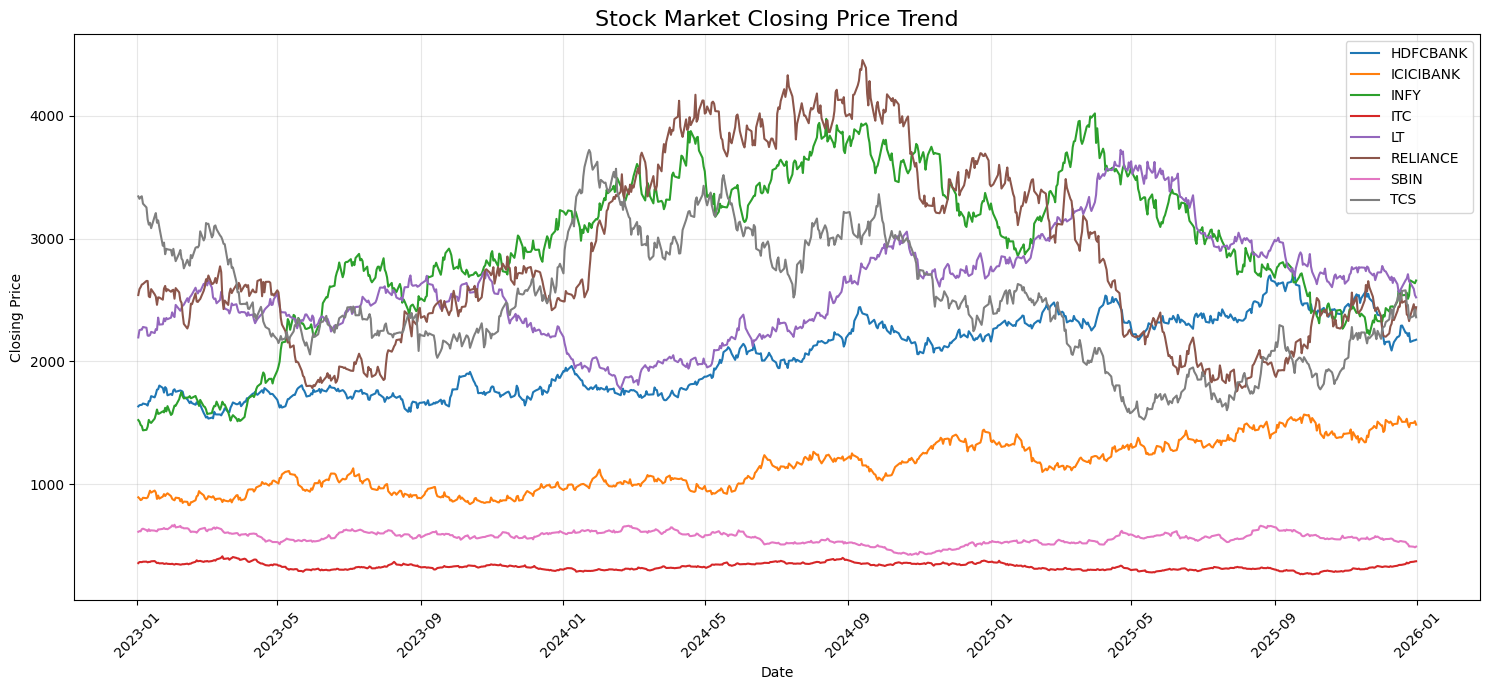

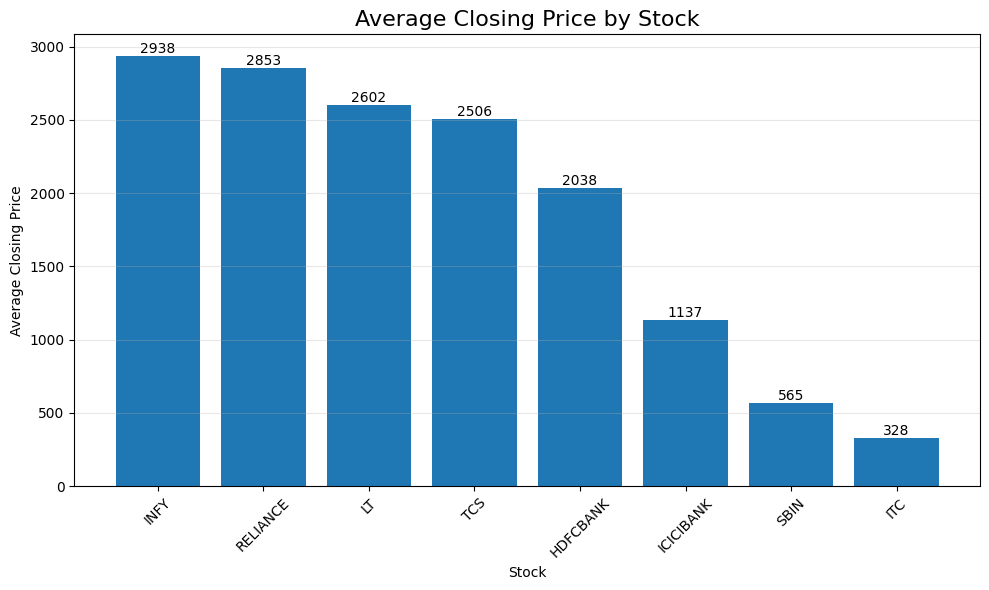

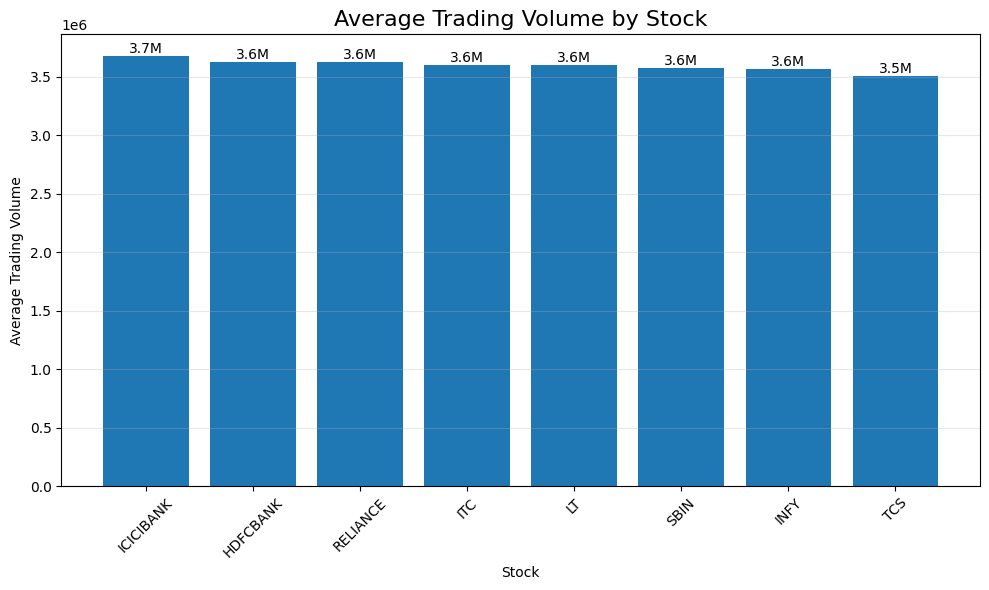

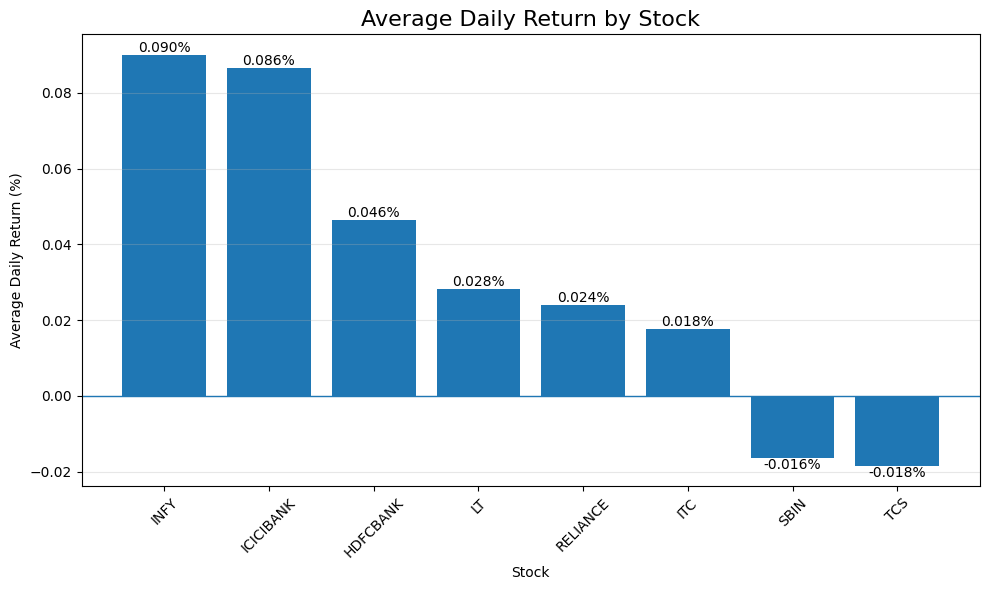

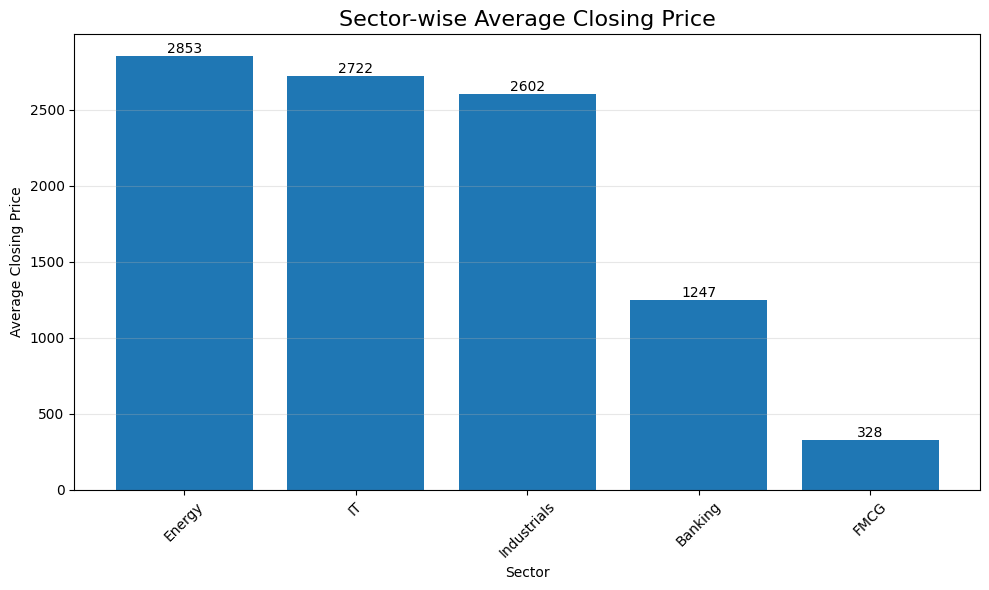

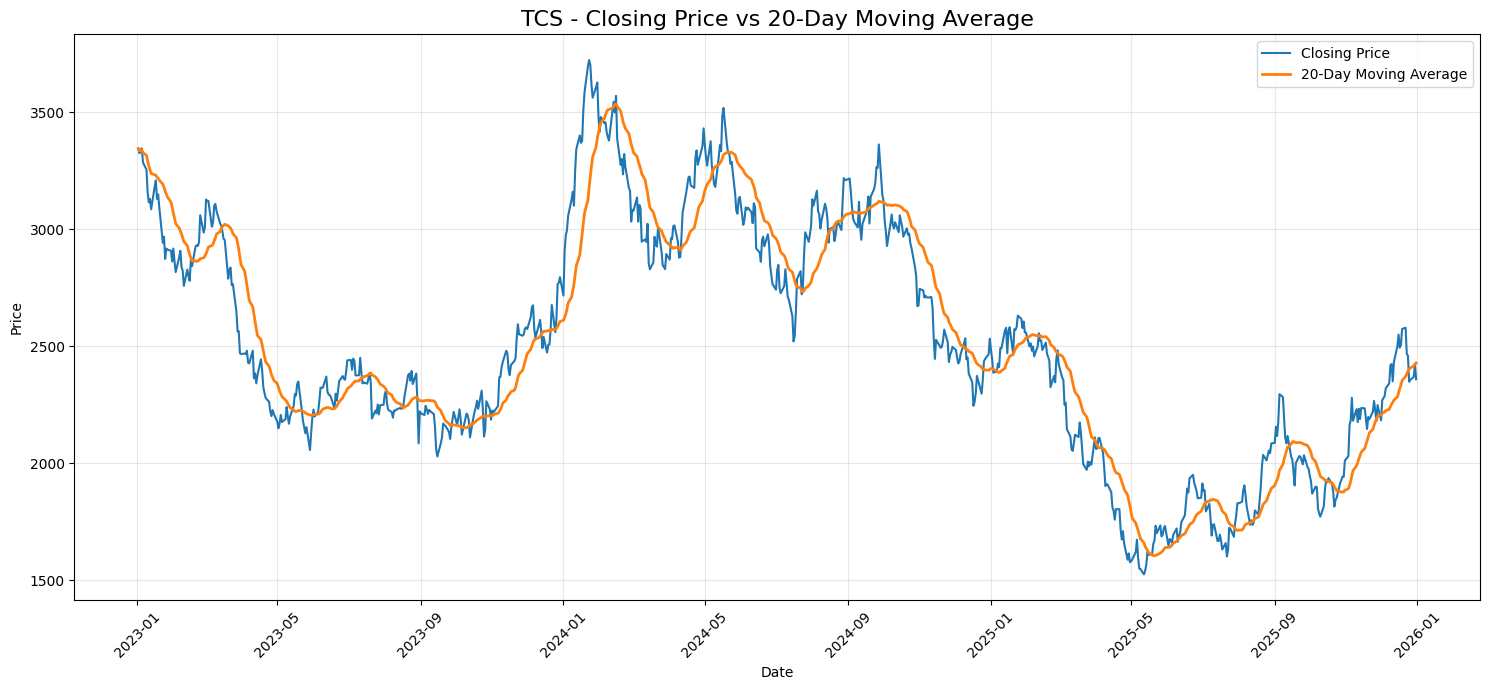


       STOCK MARKET ANALYSIS SUMMARY

Number of Stocks: 8
Number of Sectors: 5
Total Records: 6264

Stocks:
['HDFCBANK' 'ICICIBANK' 'INFY' 'ITC' 'LT' 'RELIANCE' 'SBIN' 'TCS']

Sectors:
['Banking' 'IT' 'FMCG' 'Industrials' 'Energy']

Average Closing Price:


,Average Close
Ticker,
HDFCBANK,2038.21
ICICIBANK,1136.65
INFY,2937.54
ITC,328.07
LT,2601.71
RELIANCE,2852.91
SBIN,564.87
TCS,2506.47



Average Daily Return:


,Average Daily Return (%)
Ticker,
HDFCBANK,0.0464
ICICIBANK,0.0864
INFY,0.0900
ITC,0.0177
LT,0.0283
RELIANCE,0.0239
SBIN,-0.0163
TCS,-0.0184



Average Trading Volume:


,Average Volume
Ticker,
HDFCBANK,3631031.0
ICICIBANK,3679578.0
INFY,3564647.0
ITC,3603963.0
LT,3601096.0
RELIANCE,3623910.0
SBIN,3578401.0
TCS,3509656.0



             ANALYSIS COMPLETED


In [1]:
# ============================================================
# STOCK MARKET ANALYSIS - GOOGLE COLAB
# 6 VISUALIZATIONS
# ============================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

# -----------------------------
# 2. UPLOAD CSV FILE
# -----------------------------
print("Upload: stock_market_analysis_dataset.csv")

uploaded = files.upload()

# Automatically find the uploaded CSV
file_name = list(uploaded.keys())[0]

# Read dataset
df = pd.read_csv(file_name)

# Convert Date column
df["Date"] = pd.to_datetime(df["Date"])

# Sort data
df = df.sort_values(["Ticker", "Date"])

print("\nDataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

display(df.head())


# ============================================================
# VISUALIZATION 1
# STOCK CLOSING PRICE TREND
# ============================================================

plt.figure(figsize=(15, 7))

for ticker in df["Ticker"].unique():
    stock = df[df["Ticker"] == ticker]

    plt.plot(
        stock["Date"],
        stock["Close"],
        label=ticker,
        linewidth=1.5
    )

plt.title("Stock Market Closing Price Trend", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# VISUALIZATION 2
# AVERAGE CLOSING PRICE BY STOCK
# ============================================================

avg_close = (
    df.groupby("Ticker")["Close"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    avg_close.index,
    avg_close.values
)

plt.title("Average Closing Price by Stock", fontsize=16)
plt.xlabel("Stock")
plt.ylabel("Average Closing Price")

# Display values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.0f}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# VISUALIZATION 3
# AVERAGE TRADING VOLUME BY STOCK
# ============================================================

avg_volume = (
    df.groupby("Ticker")["Volume"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    avg_volume.index,
    avg_volume.values
)

plt.title("Average Trading Volume by Stock", fontsize=16)
plt.xlabel("Stock")
plt.ylabel("Average Trading Volume")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height/1e6:.1f}M",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# VISUALIZATION 4
# AVERAGE DAILY RETURN BY STOCK
# ============================================================

avg_return = (
    df.groupby("Ticker")["Daily_Return_%"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    avg_return.index,
    avg_return.values
)

plt.title("Average Daily Return by Stock", fontsize=16)
plt.xlabel("Stock")
plt.ylabel("Average Daily Return (%)")

for bar in bars:
    height = bar.get_height()

    if height >= 0:
        y_position = height
    else:
        y_position = height

    plt.text(
        bar.get_x() + bar.get_width()/2,
        y_position,
        f"{height:.3f}%",
        ha="center",
        va="bottom" if height >= 0 else "top"
    )

plt.axhline(0, linewidth=1)
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# VISUALIZATION 5
# SECTOR-WISE AVERAGE CLOSING PRICE
# ============================================================

sector_price = (
    df.groupby("Sector")["Close"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

bars = plt.bar(
    sector_price.index,
    sector_price.values
)

plt.title("Sector-wise Average Closing Price", fontsize=16)
plt.xlabel("Sector")
plt.ylabel("Average Closing Price")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.0f}",
        ha="center",
        va="bottom"
    )

plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# ============================================================
# VISUALIZATION 6
# STOCK PRICE VS 20-DAY MOVING AVERAGE
# ============================================================

# Choose stock
selected_stock = "TCS"

stock = df[df["Ticker"] == selected_stock].copy()

plt.figure(figsize=(15, 7))

plt.plot(
    stock["Date"],
    stock["Close"],
    label="Closing Price",
    linewidth=1.5
)

plt.plot(
    stock["Date"],
    stock["Moving_Avg_20"],
    label="20-Day Moving Average",
    linewidth=2
)

plt.title(
    f"{selected_stock} - Closing Price vs 20-Day Moving Average",
    fontsize=16
)

plt.xlabel("Date")
plt.ylabel("Price")

plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ============================================================
# ADDITIONAL ANALYSIS
# ============================================================

print("\n==============================================")
print("       STOCK MARKET ANALYSIS SUMMARY")
print("==============================================")

print("\nNumber of Stocks:",
      df["Ticker"].nunique())

print("Number of Sectors:",
      df["Sector"].nunique())

print("Total Records:",
      len(df))

print("\nStocks:")
print(df["Ticker"].unique())

print("\nSectors:")
print(df["Sector"].unique())


# Average price
print("\nAverage Closing Price:")
display(
    df.groupby("Ticker")["Close"]
    .mean()
    .round(2)
    .to_frame("Average Close")
)


# Average return
print("\nAverage Daily Return:")
display(
    df.groupby("Ticker")["Daily_Return_%"]
    .mean()
    .round(4)
    .to_frame("Average Daily Return (%)")
)


# Average volume
print("\nAverage Trading Volume:")
display(
    df.groupby("Ticker")["Volume"]
    .mean()
    .round(0)
    .to_frame("Average Volume")
)


print("\n==============================================")
print("             ANALYSIS COMPLETED")
print("==============================================")